# PyTorch Tensors Tutorial


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

torch.__version__

'2.8.0'

In [2]:
# Helper function to summarize the properties of a tensor
def describe(x):
    print(f"Python Type :: {type(x)}")
    print(f"Tensor Type :: {x.type()}")
    print(f"Data Type  :: {x.dtype}")
    
    # torch.Size is in fact a tuple, so it supports all tuple operations.
    print(f"Shape/Size :: {x.shape}")
    print(f"Number of elements :: {x.numel()}")

    # Dimension :: x.ndimension()
    print(f"Dimension :: {x.dim()}")
    print(f"Data :: \n{x}")
    print('-----'*5)

# Tensors

A PyTorch tensor is a data structure similar to NumPy arrays. It generalizes vectors and matrices to an arbitrary number of dimensions. The dimensionality of a tensor corresponds to the number of indices used to refer to scalar values within the tensor.

Compared to NumPy arrays, PyTorch tensors can:
- Run on GPUs for faster computation
- Distribute operations across multiple devices
- Keep track of the computation graph (for automatic differentiation)

## Creating Tensors

### Scalar (0-d Tensor)

In [3]:
# Scalar (0-d Tensor) - a single value with no dimensions
s = torch.tensor(2504)
describe(s)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([])
Number of elements :: 1
Dimension :: 0
Data :: 
2504
-------------------------


### Vector (1-d Tensor)

#### Constructing a Tensor directly using python list

##### Using `Tensor` object

In [4]:
m = torch.Tensor([25, 4])
describe(m)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.FloatTensor
Data Type  :: torch.float32
Shape/Size :: torch.Size([2])
Number of elements :: 2
Dimension :: 1
Data :: 
tensor([25.,  4.])
-------------------------


**NOTE:** `torch.Tensor()` always creates a `FloatTensor`. However, this is not commonly used nowadays. The recommended method is to use `torch.tensor()`.

##### Changing Data type of tensor using `tensor.type()`

In [5]:
print("Original type of tensor m : ", m.type())
print("")
m = m.type(torch.LongTensor)
print("Changed type of tensor m : ", m.type())

Original type of tensor m :  torch.FloatTensor

Changed type of tensor m :  torch.LongTensor


##### Using `tensor()` method

In [6]:
m = torch.tensor([25, 4])
describe(m)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([2])
Number of elements :: 2
Dimension :: 1
Data :: 
tensor([25,  4])
-------------------------


- `torch.tensor()` infers the data type automatically
- `torch.Tensor()` is an alias of `torch.FloatTensor()`
- **Prefer `torch.tensor()`** - it allows explicit dtype specification and infers types from data if not specified

##### Integer and Float lists to Tensor

In [7]:
int_list = [1,2,3,4,5]
float_list = [1.0,2.0,3.0,4.0,5.0]

In [8]:
int_tensor = torch.tensor(int_list)
describe(int_tensor)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([5])
Number of elements :: 5
Dimension :: 1
Data :: 
tensor([1, 2, 3, 4, 5])
-------------------------


In [9]:
float_int_tensor = torch.tensor(float_list, dtype=torch.int64)
describe(float_int_tensor)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([5])
Number of elements :: 5
Dimension :: 1
Data :: 
tensor([1, 2, 3, 4, 5])
-------------------------


In [10]:
int_float_tensor = torch.FloatTensor(int_list)
describe(int_float_tensor)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.FloatTensor
Data Type  :: torch.float32
Shape/Size :: torch.Size([5])
Number of elements :: 5
Dimension :: 1
Data :: 
tensor([1., 2., 3., 4., 5.])
-------------------------


##### `dtype` conversion

In [11]:
int_tensor, int_tensor.dtype

(tensor([1, 2, 3, 4, 5]), torch.int64)

In [12]:
int_tensor.double()

tensor([1., 2., 3., 4., 5.], dtype=torch.float64)

In [13]:
int_tensor.to(torch.short)

tensor([1, 2, 3, 4, 5], dtype=torch.int16)

If there is mix type, pytorch will automatically upgrade the tensor to broader dtype

In [14]:
arr = [1, 2.0, 3, 4.5]
mixed_tensor = torch.tensor(arr)
describe(mixed_tensor)
#The dtype is float32 as it is the broader type between int and float

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.FloatTensor
Data Type  :: torch.float32
Shape/Size :: torch.Size([4])
Number of elements :: 4
Dimension :: 1
Data :: 
tensor([1.0000, 2.0000, 3.0000, 4.5000])
-------------------------


- `float32` is generally used for all Neural Networks. This is the default dtype.
- `int8` is generally used for memory optimization.

##### Tensor to list using `to_list()`

In [15]:
int_tensor.tolist()

[1, 2, 3, 4, 5]

#### Matrix (2-d)

In [16]:
#Constructing a Tensor directly 
#Creates an unitilised matrix of size 5x4
c = torch.Tensor(5,4)
describe(c)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.FloatTensor
Data Type  :: torch.float32
Shape/Size :: torch.Size([5, 4])
Number of elements :: 20
Dimension :: 2
Data :: 
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
-------------------------


### Using numpy array

#### Initialising with numpy array

In [17]:
#Initialized with numpy array
n = torch.tensor(np.array([25, 4], dtype=np.int32))
describe(n)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.IntTensor
Data Type  :: torch.int32
Shape/Size :: torch.Size([2])
Number of elements :: 2
Dimension :: 1
Data :: 
tensor([25,  4], dtype=torch.int32)
-------------------------


#### Creating tensor from numpy array using `.from_numpy()`

In [18]:
a = np.random.rand(10)
print(a)
print(type(a))
print("-----------------------------------------")
tensor_a = torch.from_numpy(a)
describe(tensor_a)

[0.88433729 0.93605124 0.9919565  0.07355756 0.12325563 0.13631532
 0.55647087 0.2970646  0.40562984 0.29993362]
<class 'numpy.ndarray'>
-----------------------------------------
Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.DoubleTensor
Data Type  :: torch.float64
Shape/Size :: torch.Size([10])
Number of elements :: 10
Dimension :: 1
Data :: 
tensor([0.8843, 0.9361, 0.9920, 0.0736, 0.1233, 0.1363, 0.5565, 0.2971, 0.4056,
        0.2999], dtype=torch.float64)
-------------------------


`from_numpy()` creates a tensor that shares memory with the numpy array. So, changing one will change the other.

In [19]:
a = np.random.rand(3,4)
print(a)
tensor_a
describe(tensor_a)

[[0.71758414 0.52302545 0.08361844 0.17523748]
 [0.20010876 0.84303941 0.91169615 0.92754236]
 [0.82598669 0.53091345 0.42675081 0.21334176]]
Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.DoubleTensor
Data Type  :: torch.float64
Shape/Size :: torch.Size([10])
Number of elements :: 10
Dimension :: 1
Data :: 
tensor([0.8843, 0.9361, 0.9920, 0.0736, 0.1233, 0.1363, 0.5565, 0.2971, 0.4056,
        0.2999], dtype=torch.float64)
-------------------------


#### Converting Tensor to numpy array using `.numpy()`

In [20]:
back_to_numpy_a = tensor_a.numpy()
back_to_numpy_a, back_to_numpy_a.dtype

(array([0.88433729, 0.93605124, 0.9919565 , 0.07355756, 0.12325563,
        0.13631532, 0.55647087, 0.2970646 , 0.40562984, 0.29993362]),
 dtype('float64'))

### From Pandas Series & Dataframe

There is no direct conversion from `dataframe` or `series` to tensor. First the `df` object gets converted to `nd-array` and then to `tensor`.  

#### series --> nd-array --> tensor

In [21]:
pd_series = pd.Series(np.arange(1,11,2))
print(pd_series)
print(type(pd_series))
print("------------------------------------------")
tensor_from_series = torch.from_numpy(pd_series.values)
describe(tensor_from_series)

0    1
1    3
2    5
3    7
4    9
dtype: int64
<class 'pandas.core.series.Series'>
------------------------------------------
Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([5])
Number of elements :: 5
Dimension :: 1
Data :: 
tensor([1, 3, 5, 7, 9])
-------------------------


#### dataframe --> nd array --> tensor

In [22]:
df = pd.DataFrame({'a':[11,21,31],'b':[12,22,32], 'c':[13,23,33]})
print(df)
print(type(df))
print("")

# Since there is no direct conversion from dataframe to tensor, first convert to nd-array then to tensor
# .values returns the nd-array representation of the dataframe
tensor_fron_dataframe = torch.from_numpy(df.values)
describe(tensor_fron_dataframe)

    a   b   c
0  11  12  13
1  21  22  23
2  31  32  33
<class 'pandas.core.frame.DataFrame'>

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([3, 3])
Number of elements :: 9
Dimension :: 2
Data :: 
tensor([[11, 12, 13],
        [21, 22, 23],
        [31, 32, 33]])
-------------------------


### Default Tensor Options

`torch.empty()` - Creates an unitialised tensor

In [23]:
empt = torch.empty(10)
describe(empt)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.FloatTensor
Data Type  :: torch.float32
Shape/Size :: torch.Size([10])
Number of elements :: 10
Dimension :: 1
Data :: 
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
-------------------------


`torch.zeros()` - Creates a tensor initialised with zeros

In [24]:
z = torch.zeros(2,3,4)
describe(z)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.FloatTensor
Data Type  :: torch.float32
Shape/Size :: torch.Size([2, 3, 4])
Number of elements :: 24
Dimension :: 3
Data :: 
tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])
-------------------------


`torch.ones()` - Creates a tensor initialised with ones

In [25]:
#torch.ones()
#_like :: Creating a tensor using the existing Tensor; 
#         These methods will reuse properties of the input tensor, e.g. dtype, unless new values are provided
o = torch.ones_like(z)
describe(o)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.FloatTensor
Data Type  :: torch.float32
Shape/Size :: torch.Size([2, 3, 4])
Number of elements :: 24
Dimension :: 3
Data :: 
tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])
-------------------------


`torch.fill()` - Creates a tensor filled with the same value

In [26]:
#torch.fill(shape, val)
z.fill_(25) #_ ===> in-place operation
describe(z)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.FloatTensor
Data Type  :: torch.float32
Shape/Size :: torch.Size([2, 3, 4])
Number of elements :: 24
Dimension :: 3
Data :: 
tensor([[[25., 25., 25., 25.],
         [25., 25., 25., 25.],
         [25., 25., 25., 25.]],

        [[25., 25., 25., 25.],
         [25., 25., 25., 25.],
         [25., 25., 25., 25.]]])
-------------------------


`torch.diag()` - Creates a Diagonal Matrix using the input tensor

In [27]:
#Creating a diagonal matrix tensor using the input data
#input data must be a torch tensor
d = torch.diag(torch.tensor([1,2,3,4]))
describe(d)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([4, 4])
Number of elements :: 16
Dimension :: 2
Data :: 
tensor([[1, 0, 0, 0],
        [0, 2, 0, 0],
        [0, 0, 3, 0],
        [0, 0, 0, 4]])
-------------------------


`torch.eye()` - Creates an Identity Matrix using the input dimension

In [28]:
#Creating an identity matrix
#default dtype is float
i = torch.eye(5,5, dtype=torch.int64)
describe(i)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([5, 5])
Number of elements :: 25
Dimension :: 2
Data :: 
tensor([[1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1]])
-------------------------


`torch.rand()`, `torch.randn()`, `torch.randint()` - Creates a tensor initialised with random values

In [29]:
#Creates a tensor insitialised with 10 uniform random values
x = torch.rand(2,5)
describe(x)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.FloatTensor
Data Type  :: torch.float32
Shape/Size :: torch.Size([2, 5])
Number of elements :: 10
Dimension :: 2
Data :: 
tensor([[0.6709, 0.9410, 0.3576, 0.9607, 0.8555],
        [0.9406, 0.9904, 0.4338, 0.7638, 0.8088]])
-------------------------


In [30]:
#Creating a normal distribution tensor of shape x
#x_normal = torch.randn(shape)
x_normal = torch.randn_like(x)
describe(x_normal)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.FloatTensor
Data Type  :: torch.float32
Shape/Size :: torch.Size([2, 5])
Number of elements :: 10
Dimension :: 2
Data :: 
tensor([[-0.7629, -2.2636, -0.2427, -0.0991, -0.7114],
        [ 1.3291,  1.4940,  1.8723,  0.7934, -2.9974]])
-------------------------


In [31]:
# randint(start, end, size(must be a tuple))
rand_ints = torch.randint(0, 100, (5, 4))
describe(rand_ints)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([5, 4])
Number of elements :: 20
Dimension :: 2
Data :: 
tensor([[97, 61, 76,  9],
        [10, 15, 25,  8],
        [92, 64, 35, 59],
        [68, 68, 42, 30],
        [ 2, 51, 91, 91]])
-------------------------


##### Using Sequences

`torch.linspace()` - Creates a tensor with evenly spaced values.

In [32]:
#linspace(start, end, number of elements)
# Linespace returns evenly spaced numbers over a specified interval.
ls = torch.linspace(20, 30, 100)
describe(ls)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.FloatTensor
Data Type  :: torch.float32
Shape/Size :: torch.Size([100])
Number of elements :: 100
Dimension :: 1
Data :: 
tensor([20.0000, 20.1010, 20.2020, 20.3030, 20.4040, 20.5051, 20.6061, 20.7071,
        20.8081, 20.9091, 21.0101, 21.1111, 21.2121, 21.3131, 21.4141, 21.5152,
        21.6162, 21.7172, 21.8182, 21.9192, 22.0202, 22.1212, 22.2222, 22.3232,
        22.4242, 22.5253, 22.6263, 22.7273, 22.8283, 22.9293, 23.0303, 23.1313,
        23.2323, 23.3333, 23.4343, 23.5354, 23.6364, 23.7374, 23.8384, 23.9394,
        24.0404, 24.1414, 24.2424, 24.3434, 24.4444, 24.5455, 24.6465, 24.7475,
        24.8485, 24.9495, 25.0505, 25.1515, 25.2525, 25.3535, 25.4545, 25.5556,
        25.6566, 25.7576, 25.8586, 25.9596, 26.0606, 26.1616, 26.2626, 26.3636,
        26.4646, 26.5657, 26.6667, 26.7677, 26.8687, 26.9697, 27.0707, 27.1717,
        27.2727, 27.3737, 27.4747, 27.5758, 27.6768, 27.7778, 27.8788, 27.9798,
        28.0808, 28

`torch.range()` or `torch.arrange()` - Creates a tensor consisting of range of values incrementally or decrementally, depending upon the step value,

In [33]:
#range(start, end, step)
rg = torch.range(0, 100, 3)
describe(rg)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.FloatTensor
Data Type  :: torch.float32
Shape/Size :: torch.Size([34])
Number of elements :: 34
Dimension :: 1
Data :: 
tensor([ 0.,  3.,  6.,  9., 12., 15., 18., 21., 24., 27., 30., 33., 36., 39.,
        42., 45., 48., 51., 54., 57., 60., 63., 66., 69., 72., 75., 78., 81.,
        84., 87., 90., 93., 96., 99.])
-------------------------


In [34]:
arg = torch.arange(1000, 100, step=-100)
describe(arg)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([9])
Number of elements :: 9
Dimension :: 1
Data :: 
tensor([1000,  900,  800,  700,  600,  500,  400,  300,  200])
-------------------------


## Indexing & Slicing
Accessing elements, rows, columns, sub-tensor from a tensor

In [35]:
rand_ints.data

tensor([[97, 61, 76,  9],
        [10, 15, 25,  8],
        [92, 64, 35, 59],
        [68, 68, 42, 30],
        [ 2, 51, 91, 91]])

In [36]:
rand_ints[0][2]

tensor(76)

In [37]:
rand_ints[0,2]

tensor(76)

Accessing an element from a tensor returns tensor object. To get the element use `.item()`

In [38]:
rand_ints[0][2].item()

76

In [39]:
#Indexing and Slicing
#3rd row, 2nd and 3rd column
rand_ints[2, 1:3]

tensor([64, 35])

In [40]:
#Updating the tensor
rand_ints[2, 1:3] = torch.Tensor([19, 91])
rand_ints.data

tensor([[97, 61, 76,  9],
        [10, 15, 25,  8],
        [92, 19, 91, 59],
        [68, 68, 42, 30],
        [ 2, 51, 91, 91]])

In [41]:
#first column
rand_ints[:, 0]

tensor([97, 10, 92, 68,  2])

In [42]:
#first 2 row
rand_ints[:2,:]

tensor([[97, 61, 76,  9],
        [10, 15, 25,  8]])

In [43]:
#last 3 column
rand_ints[:,-3:]

tensor([[61, 76,  9],
        [15, 25,  8],
        [19, 91, 59],
        [68, 42, 30],
        [51, 91, 91]])

In [44]:
#last row
rand_ints[-1,:]

tensor([ 2, 51, 91, 91])

#### Non-contiguous row/cols indexing using `torch.index_select()`

In [45]:
#Access 2nd and 4th col
indices = torch.LongTensor([1,3]) # Index must be integers
describe(torch.index_select(rand_ints, dim=1, index=indices))

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([5, 2])
Number of elements :: 10
Dimension :: 2
Data :: 
tensor([[61,  9],
        [15,  8],
        [19, 59],
        [68, 30],
        [51, 91]])
-------------------------


In [46]:
rand_ints[:,[1,3]]

tensor([[61,  9],
        [15,  8],
        [19, 59],
        [68, 30],
        [51, 91]])

In [47]:
#access 2nd and 4th row
describe(torch.index_select(rand_ints, dim=0, index=indices))

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([2, 4])
Number of elements :: 8
Dimension :: 2
Data :: 
tensor([[10, 15, 25,  8],
        [68, 68, 42, 30]])
-------------------------


In [48]:
rand_ints[[1,3]]

tensor([[10, 15, 25,  8],
        [68, 68, 42, 30]])

#### Non-contiguous cell indexing

In [49]:
print(rand_ints.data)
idx = torch.LongTensor([[2,2], [1,3], [0,0], [3,1], [4,3]])
print(list(idx.T))
rand_ints[list(idx.T)]

tensor([[97, 61, 76,  9],
        [10, 15, 25,  8],
        [92, 19, 91, 59],
        [68, 68, 42, 30],
        [ 2, 51, 91, 91]])
[tensor([2, 1, 0, 3, 4]), tensor([2, 3, 0, 1, 3])]


tensor([91,  8, 97, 68, 91])

`list(idx.T)` this generates list of 2 tensors. The first tensor gives out row indices and the second tensor gives column indices.

#### Boolean Indexing

In [50]:
print(rand_ints.data)

# Boolean Mask using logical condition
mask = rand_ints > 50
print(mask)

# Using the boolean mask to filter values
rand_ints[mask]

tensor([[97, 61, 76,  9],
        [10, 15, 25,  8],
        [92, 19, 91, 59],
        [68, 68, 42, 30],
        [ 2, 51, 91, 91]])
tensor([[ True,  True,  True, False],
        [False, False, False, False],
        [ True, False,  True,  True],
        [ True,  True, False, False],
        [False,  True,  True,  True]])


tensor([97, 61, 76, 92, 91, 59, 68, 68, 51, 91, 91])

## Reshaping and Manipulating Tensors

### Reshaping Tensors

In [51]:
a = torch.tensor([25.0])
a = a.unsqueeze(0)
a = a.squeeze()
a

tensor(25.)

In [52]:
a = torch.arange(1, 21, dtype=torch.int32)
a.shape

torch.Size([20])

`torch.Tensor.shape` returns `torch.Size` object with size in each dimension.

`torch.Tensor.view()` reshapes a tensor. It returns a new tensor with same data but different shape.

In [53]:
reshaped_a = a.view(2,2,5)
reshaped_a.shape, reshaped_a

(torch.Size([2, 2, 5]),
 tensor([[[ 1,  2,  3,  4,  5],
          [ 6,  7,  8,  9, 10]],
 
         [[11, 12, 13, 14, 15],
          [16, 17, 18, 19, 20]]], dtype=torch.int32))

`torch.Tensor.reshape()` is also used for reshaping the Tensor.

In [54]:
res_a = a.reshape(4,5)
res_a.shape, res_a

(torch.Size([4, 5]),
 tensor([[ 1,  2,  3,  4,  5],
         [ 6,  7,  8,  9, 10],
         [11, 12, 13, 14, 15],
         [16, 17, 18, 19, 20]], dtype=torch.int32))

`reshape()` should be preferred over `view()` as it offers more flexibility, particularly in automatically handling non-contiguous memory layouts.

#### Changing Dimensions

Often times, there is a shape mismatch between created and expected tensors. And one of the common way to resolve is adding or removing a dimension

`torch.Tensor.unsqueeze()` inserts a new dimension at the specified index.

In [55]:
mat = torch.randn(4,5)
mat.shape

torch.Size([4, 5])

In [56]:
unsqueezed_mat = mat.unsqueeze(0)  #Adding a new dimension at index 0
unsqueezed_mat.shape, unsqueezed_mat

(torch.Size([1, 4, 5]),
 tensor([[[ 0.1105,  0.4686, -0.2478,  2.0156,  0.4932],
          [ 0.7340, -0.3694,  0.2651,  0.0633,  0.0033],
          [-0.6290,  0.0186, -1.3694,  0.9368,  1.4158],
          [-0.3067, -0.1537, -0.5455,  0.0301, -0.3265]]]))

`torch.squeeze()`:  Returns a tensor with all the dimensions of input of size 1 removed.

For example, if input is of shape: (A×1×B×C×1×D) then the out tensor will be of shape: (A×B×C×D) 

In [57]:
x = torch.zeros(2,1,2,1,2)
print(f"Original Shape of tensor x :: {x.size()}")
print("-----------------------------------------")
y = torch.squeeze(x)
print(f"Shape of tensor after squeeze :: {y.size()}")
print("-----------------------------------------")
y = torch.squeeze(x, dim=1)
print(f"Shape of tensor after squeeze only across dimension 1 :: {y.size()}")
print("-----------------------------------------")
y = torch.squeeze(x, dim=3)
print(f"Shape of tensor after squeeze only across dimension 3 :: {y.size()}")
print("-----------------------------------------")

Original Shape of tensor x :: torch.Size([2, 1, 2, 1, 2])
-----------------------------------------
Shape of tensor after squeeze :: torch.Size([2, 2, 2])
-----------------------------------------
Shape of tensor after squeeze only across dimension 1 :: torch.Size([2, 2, 1, 2])
-----------------------------------------
Shape of tensor after squeeze only across dimension 3 :: torch.Size([2, 1, 2, 2])
-----------------------------------------


### Joining tensors

`torch.cat()`: Concatenating sequence of tensor along a given dimension (existing axis).

All tensors must have same shape or be empty.

In [58]:
rand_ints = torch.randint(0, 10, (5, 2))
rand_ints

tensor([[5, 0],
        [3, 5],
        [1, 9],
        [4, 5],
        [5, 7]])

In [59]:
t1 = torch.cat([rand_ints, rand_ints], dim=0)
describe(t1)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([10, 2])
Number of elements :: 20
Dimension :: 2
Data :: 
tensor([[5, 0],
        [3, 5],
        [1, 9],
        [4, 5],
        [5, 7],
        [5, 0],
        [3, 5],
        [1, 9],
        [4, 5],
        [5, 7]])
-------------------------


In [60]:
t1 = torch.cat([rand_ints, rand_ints, rand_ints], dim=1)
describe(t1)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([5, 6])
Number of elements :: 30
Dimension :: 2
Data :: 
tensor([[5, 0, 5, 0, 5, 0],
        [3, 5, 3, 5, 3, 5],
        [1, 9, 1, 9, 1, 9],
        [4, 5, 4, 5, 4, 5],
        [5, 7, 5, 7, 5, 7]])
-------------------------


`torch.stack(tensors, dim=0, *, out=None)`: Concatenates a sequence of tensors along a new dimension (new axis).

In [61]:
stacked_t1 = torch.stack([rand_ints, rand_ints], dim=0)
describe(stacked_t1)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([2, 5, 2])
Number of elements :: 20
Dimension :: 3
Data :: 
tensor([[[5, 0],
         [3, 5],
         [1, 9],
         [4, 5],
         [5, 7]],

        [[5, 0],
         [3, 5],
         [1, 9],
         [4, 5],
         [5, 7]]])
-------------------------


### Splitting the tensor

`torch.chunk()`: Splits the tensor into a specific number of chunks.

In [62]:
torch.chunk(t1, 3, dim=1)

(tensor([[5, 0],
         [3, 5],
         [1, 9],
         [4, 5],
         [5, 7]]),
 tensor([[5, 0],
         [3, 5],
         [1, 9],
         [4, 5],
         [5, 7]]),
 tensor([[5, 0],
         [3, 5],
         [1, 9],
         [4, 5],
         [5, 7]]))

In [63]:
torch.chunk(t1, 3, dim=0)

(tensor([[5, 0, 5, 0, 5, 0],
         [3, 5, 3, 5, 3, 5]]),
 tensor([[1, 9, 1, 9, 1, 9],
         [4, 5, 4, 5, 4, 5]]),
 tensor([[5, 7, 5, 7, 5, 7]]))

`torch.split(tensor, split_size_or_sections, dim=0)`: Another function to split the tensor, insted of number of chunks, size of chunk needs to be passed. If the tensor_size is not divisible by split_size, last chunk will be smaller.

In [64]:
torch.split(t1, 3, dim=0)

(tensor([[5, 0, 5, 0, 5, 0],
         [3, 5, 3, 5, 3, 5],
         [1, 9, 1, 9, 1, 9]]),
 tensor([[4, 5, 4, 5, 4, 5],
         [5, 7, 5, 7, 5, 7]]))

if section, sum of section sizes must be equal to total (`1 + 2 + 3 = 6`, here number of columns)

In [65]:
torch.split(t1, [1,2,3], dim=1)

(tensor([[5],
         [3],
         [1],
         [4],
         [5]]),
 tensor([[0, 5],
         [5, 3],
         [9, 1],
         [5, 4],
         [7, 5]]),
 tensor([[0, 5, 0],
         [5, 3, 5],
         [9, 1, 9],
         [5, 4, 5],
         [7, 5, 7]]))

## Tensor Operations

### Statistical Operations

In [66]:
# For 3d tensors, dim=0 represents 2D tenasors, dim=1 represents rows, dim=2 represents column
a = torch.arange(20)
a = a.view(2,5,2)
print(a)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5],
         [ 6,  7],
         [ 8,  9]],

        [[10, 11],
         [12, 13],
         [14, 15],
         [16, 17],
         [18, 19]]])


`sum()` - sum of all the elements of tensor

In [67]:
# Sum of all elements in the tensor
print(f"Sum of all elements in the tensor: {a.sum()}") 

# Sum along dimension 0 (summing across the first dimension, reducing shape from (2, 5, 2) to (5, 2))
print(f"Sum along dim=0 (summing over the first dimension, combining both batches): \n{a.sum(dim=0)}")

# Sum along dimension 1 (summing across the second dimension, reducing shape from (2, 5, 2) to (2, 2))
print(f"Sum along dim=1 (summing over the second dimension, combining rows within each batch): \n{a.sum(dim=1)}")

# Sum along dimension 2 (summing across the third dimension, reducing shape from (2, 5, 2) to (2, 5))
print(f"Sum along dim=2 (summing over the third dimension, combining columns within each row): \n{a.sum(dim=2)}")

Sum of all elements in the tensor: 190
Sum along dim=0 (summing over the first dimension, combining both batches): 
tensor([[10, 12],
        [14, 16],
        [18, 20],
        [22, 24],
        [26, 28]])
Sum along dim=1 (summing over the second dimension, combining rows within each batch): 
tensor([[20, 25],
        [70, 75]])
Sum along dim=2 (summing over the third dimension, combining columns within each row): 
tensor([[ 1,  5,  9, 13, 17],
        [21, 25, 29, 33, 37]])


All the statistical operations mentioned below accepts `dim` (dimension) as parameter to perform the operation in similar way.

`torch.mean()` - calculates mean of all the elements.

In [68]:
a.float().mean()

tensor(9.5000)

`torch.std()` - calculates standard deviation of all the elements.

In [69]:
a.float().std()

tensor(5.9161)

`torch.max()` - calculates maximum of all the elements.

In [70]:
a.max()

tensor(19)

`torch.min()` - calculates minimum of all the elements.

In [71]:
a.min()

tensor(0)

### Other mathematical operations

In [72]:
tnsr = torch.linspace(0, 2*np.pi, 100)
sin_tnsr = torch.sin(tnsr)

In [73]:
# command "matplotlib inline" to display the plot.
%matplotlib inline

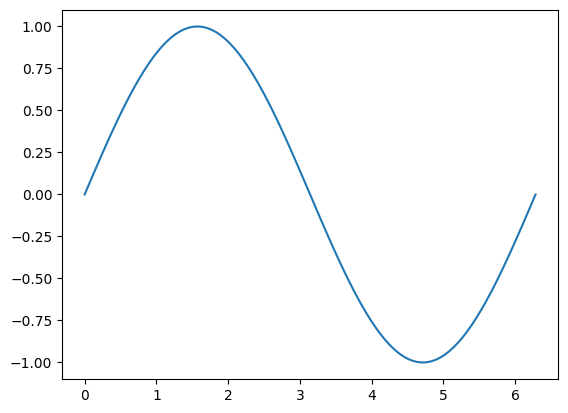

In [74]:
plt.plot(tnsr.numpy(), sin_tnsr.numpy())

Check this [link](https://pytorch.org/docs/stable/torch.html#) for more tensor operations.

### Arithmetic Operations

In [75]:
#Arithmetic operations +, -, *, /
a = torch.randint(0,10,(2,2))
print(a)
b = torch.randint(0,10,(2,2))
print(b)

c = a+b
c

tensor([[3, 8],
        [1, 1]])
tensor([[8, 7],
        [0, 0]])


tensor([[11, 15],
        [ 1,  1]])

In [76]:
#_ signifies for inplace operation(Here, addition)
a.add_(b)

tensor([[11, 15],
        [ 1,  1]])

In [77]:
a = torch.tensor([10,20,30])
b = a.reshape(3,1)

describe(a)
describe(b)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([3])
Number of elements :: 3
Dimension :: 1
Data :: 
tensor([10, 20, 30])
-------------------------
Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([3, 1])
Number of elements :: 3
Dimension :: 2
Data :: 
tensor([[10],
        [20],
        [30]])
-------------------------


In [78]:
a+b

tensor([[20, 30, 40],
        [30, 40, 50],
        [40, 50, 60]])

Pytorch supports **broadcasting**, automatic expansion of smaller tensor to larger tensor. This allows operation between tensors with compatible shapes, even if they have different dimensions. 

`*` or `mul()` signifies element wise multiplication operation. Also known as *Hamdard Product*

In [79]:
a

tensor([10, 20, 30])

In [80]:
a * b

tensor([[100, 200, 300],
        [200, 400, 600],
        [300, 600, 900]])

In [81]:
a * 4

tensor([ 40,  80, 120])

### Logical Operations

Tensors supports:
- **Comparison Operators** (`<`, `>`, `==`)
- **Logical Operators** (`&` for **AND** and `|` for **OR**)

In [82]:
x = torch.randint(0, 100, (5,))
describe(x)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([5])
Number of elements :: 5
Dimension :: 1
Data :: 
tensor([87, 43, 13,  7, 89])
-------------------------


In [83]:
is_greater_than_50 = x > 50
print(f"Values greater than 50 : {is_greater_than_50}")

is_between_30_and_60 = (x > 30) & (x < 60)
print(f"Values between 30 and 60 : {is_between_30_and_60}")

is_multiple_of_5 = x % 5 == 0
print(f"Values which are multiple of 5 : {is_multiple_of_5}")

Values greater than 50 : tensor([ True, False, False, False,  True])
Values between 30 and 60 : tensor([False,  True, False, False, False])
Values which are multiple of 5 : tensor([False, False, False, False, False])


In [84]:
greater_50_and_multiple_of_5 = is_greater_than_50 & is_multiple_of_5
print(f"Values greater than 50 and multiple of 5 : {greater_50_and_multiple_of_5}")

Values greater than 50 and multiple of 5 : tensor([False, False, False, False, False])


### Linear Algebra

In [85]:
x1 = torch.arange(6).view(2,3)
x2 = torch.randint(1, 11, (3,1))
print("x1", "\n============")
describe(x1)
print("============\n")
print("x2", "\n============")
describe(x2)

x1 
Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([2, 3])
Number of elements :: 6
Dimension :: 2
Data :: 
tensor([[0, 1, 2],
        [3, 4, 5]])
-------------------------

x2 
Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([3, 1])
Number of elements :: 3
Dimension :: 2
Data :: 
tensor([[8],
        [5],
        [1]])
-------------------------


In [86]:
print("============\n")
print("x1 matmul x2", "\n============")
describe(torch.matmul(x1, x2))


x1 matmul x2 
Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([2, 1])
Number of elements :: 2
Dimension :: 2
Data :: 
tensor([[ 7],
        [49]])
-------------------------


In [87]:
print("============\n")
print("x1 transpose", "\n============")
describe(torch.transpose(x1, 0, 1))
print("============\n")


x1 transpose 
Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([3, 2])
Number of elements :: 6
Dimension :: 2
Data :: 
tensor([[0, 3],
        [1, 4],
        [2, 5]])
-------------------------



In [88]:
#Vector Dot Product
v1 = torch.tensor([1,2,3])
v2 = torch.tensor([4,5,6])
describe(v1.dot(v2))

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([])
Number of elements :: 1
Dimension :: 0
Data :: 
32
-------------------------


In [89]:
dp = torch.dot(v1, v2)
describe(dp)

Python Type :: <class 'torch.Tensor'>
Tensor Type :: torch.LongTensor
Data Type  :: torch.int64
Shape/Size :: torch.Size([])
Number of elements :: 1
Dimension :: 0
Data :: 
32
-------------------------


### Tensor on GPU

In [90]:
#Tensors can be moved to any device.
#Following code checks if GPU is available, make GPU (mps, if mac. cuda, if nvidia GPU) default device.
if torch.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# use ``torch.device`` objects to move tensors in and out of GPU
x3 = torch.rand(2,5).to(device)
if device == "cuda":
    print(torch.cuda.get_device_name(0))
    print(x3.type())
else:
    print(device)
    print(x3.type())

mps
torch.mps.FloatTensor
